In [1]:
# utils
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

#sk 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans

#plot
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd 


### One basin, with timeline

##### Technical procedure:
- get cell states (predictors) and matching temp timeseries (target) (matching regarding the 365 warmup and also the inherent availability of discharge data maybe use dates)
- split into train- and test-set and train, return R² and RMSE 

_notes:_
- _don't return dataset, but return model and metadata (train period, test period, metrics)_

In [2]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states.p", "rb") as f: 
	cell_states = pickle.load(f)

In [3]:
with open("/home/wuhlmann/BA/data/processed_data/eda/normal_periods.pkl", "rb") as f: 
	discharge_coverage = pickle.load(f)

In [4]:
discharge_coverage.loc[1,:]

timeseries_length                                                     8036
start_date                                             1996-01-01 00:00:00
end_date                                               2017-12-31 00:00:00
n_normal_days                                                         7098
q5_q95_normal_periods    [[1996-01-04 00:00:00, 1996-01-05 00:00:00], [...
Name: 1, dtype: object

In [5]:
ts_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries")

In [6]:
path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries/daily")
model_coef = []

for basin_id in []: 

	ts = pd.read_table(ts_path / f"ID_{basin_id}.csv", header=0, sep=";")

	ts["date"] = pd.to_datetime(
				ts[["YYYY", "MM", "DD"]].rename(columns={"YYYY": "year", "MM": "month", "DD": "day"})
			)
	ts.set_index("date", inplace=True)

	# drop all columns except for 2m_mean_temp
	ts = ts[["2m_temp_mean"]]

	ts  = ts[discharge_coverage.loc[basin_id,"start_date"]:discharge_coverage.loc[basin_id, "end_date"]]
	c = StandardScaler().fit_transform(cell_states[str(basin_id)]["c_last"])
	
	ts =ts.iloc[-len(c):]
	
	print(f"diff of ts and c len: {len(ts) -len(c)}")
	dataset = np.c_[c, ts.values]

	model = ElasticNet()
	kfold = KFold(n_splits=5)
	folds = list(kfold.split(dataset[:,:-1], dataset[:,-1]))

	fig, axs = plt.subplots(5,1, figsize=(30,20))

	best_r2 = -100
	best_model_id = None
	coef_list = []

	for i, f, ax in zip([0,1,2,3,4],folds, axs):
		
		train_ids = f[0]
		test_ids = f[1]

		target = dataset[:,-1][test_ids]

		model.fit(X=dataset[:,:-1][train_ids], y=dataset[:,-1][train_ids])
		pred = model.predict(X=dataset[:,:-1][test_ids])

		coef_list.append(model.coef_)

		r2 = r2_score(target, pred)

		if r2 > best_r2: 
			best_r2 = r2
			best_model_id = i

		print(f"R2 of {r2:.2f} | MAE of {mean_absolute_error(target, pred)}")

		ax.plot(ts.index[test_ids], target, color="red", linewidth=0.4)
		ax.plot(ts.index[test_ids], pred, color="blue", linewidth=0.4)

	model_coef.append(coef_list[best_model_id])


we use c of day of prediction, since it most acuratly represents the condition of the day the model predicts

### Basin probes visualization

In [ ]:
save_figs = False 

In [3]:
with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_2m_temp_mean_basin_probe.p", "rb") as f: 
	temp_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_prec_basin_probe.p", "rb") as f: 
	prec_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_total_et_basin_probe.p", "rb") as f: 
	total_et_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_swe_basin_probe.p", "rb") as f: 
	swe_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_volsw_123_basin_probe.p", "rb") as f: 
	volsw_123_probe_results = pickle.load(f)

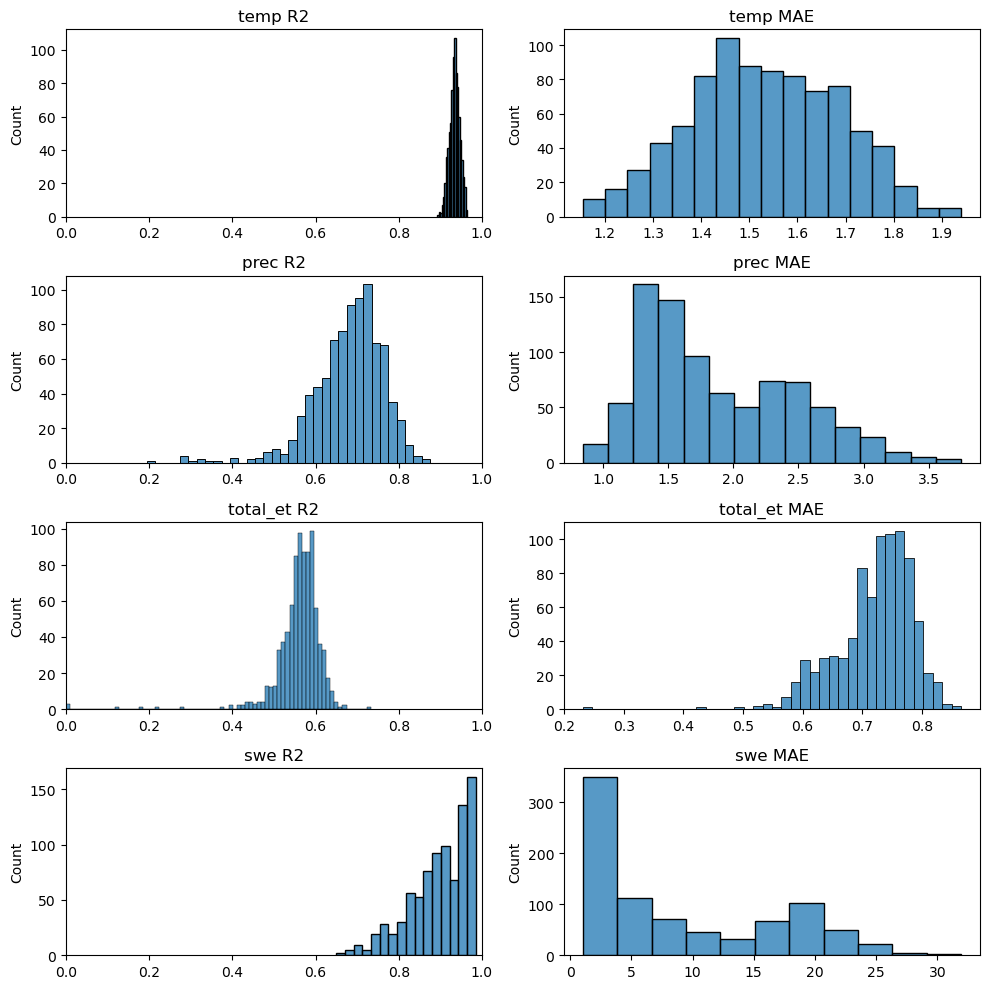

In [4]:
fig, axs = plt.subplots(4,2, figsize=(10,10))
axs = axs.ravel()

for i, probe, name in zip(
	list(range(0,8,2)),
	[temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
	["temp", "prec", "total_et", "swe"]
	):
	 
	basin_keys = list(probe.keys())[1:]

	basins_r2 = [probe[b]["R2"] for b in basin_keys]
	basins_mae = [probe[b]["MAE"] for b in basin_keys]

	sns.histplot(basins_r2, ax=axs[i])
	axs[i].set_title(f"{name} R2")
	axs[i].set_xlim(0,1)
	sns.histplot(basins_mae, ax=axs[i+1])
	axs[i+1].set_title(f"{name} MAE")

plt.tight_layout()

In [4]:
strata_ids = pd.read_table("/home/wuhlmann/BA/data/processed_data/test_splits/strata_ids_incl_651.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [5]:
strata_labels = {
	0: "alpine",
	1: "plateau",
	2: "transition"
}

In [6]:
def relevance_check(cell_state_col: pd.Series, participation_threshold: float) -> bool: 

	if (cell_state_col !=0).sum() >= len(cell_state_col) * participation_threshold:  
		return True
	else:
		return False

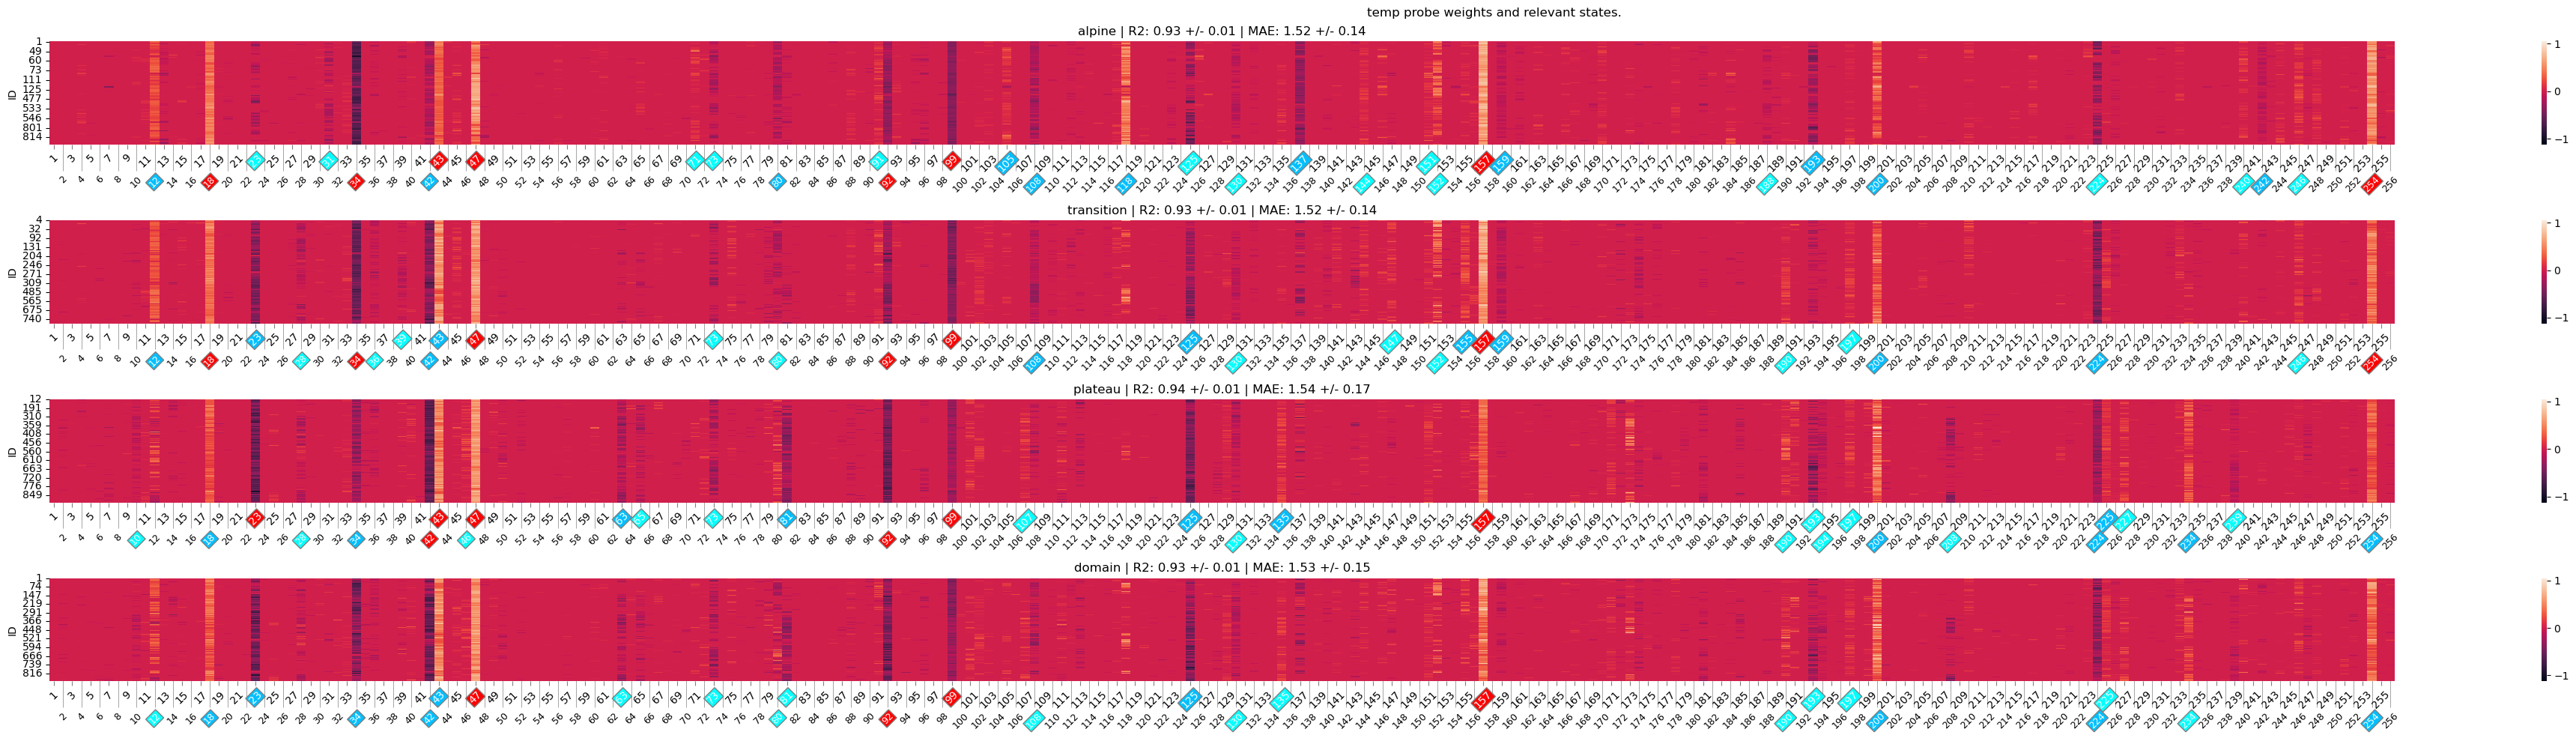

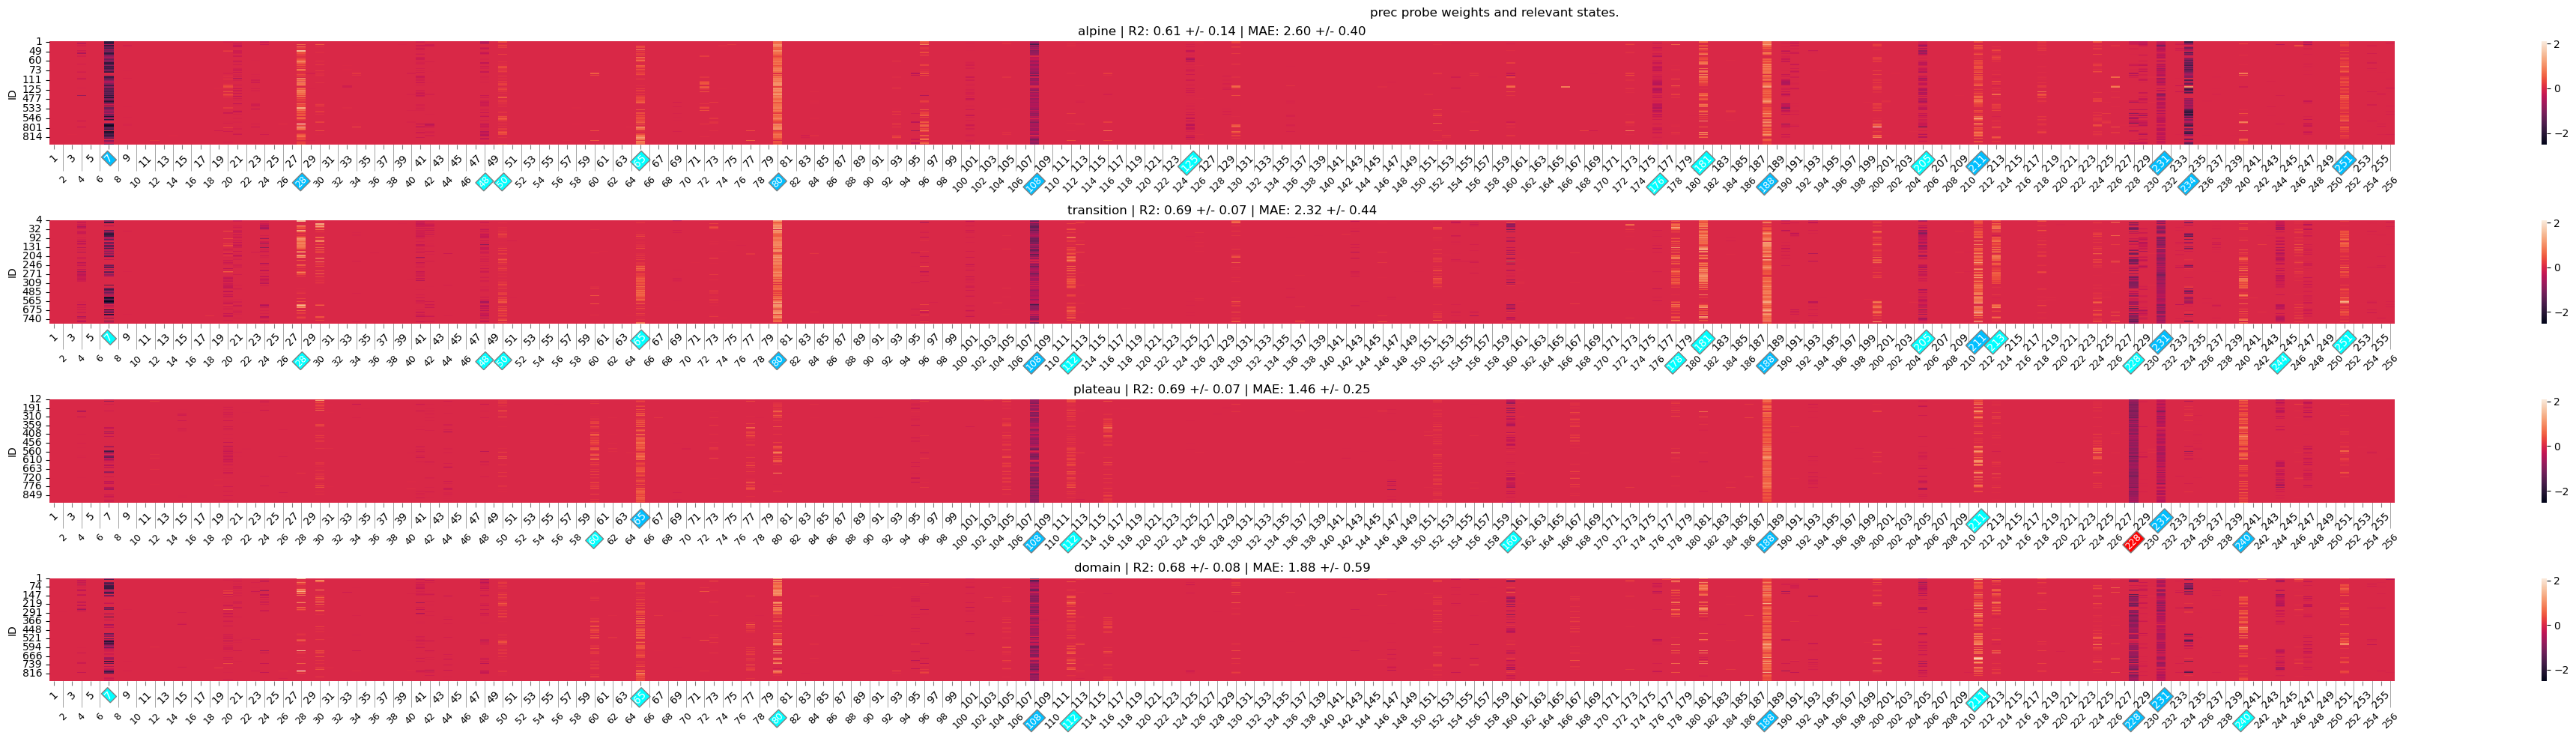

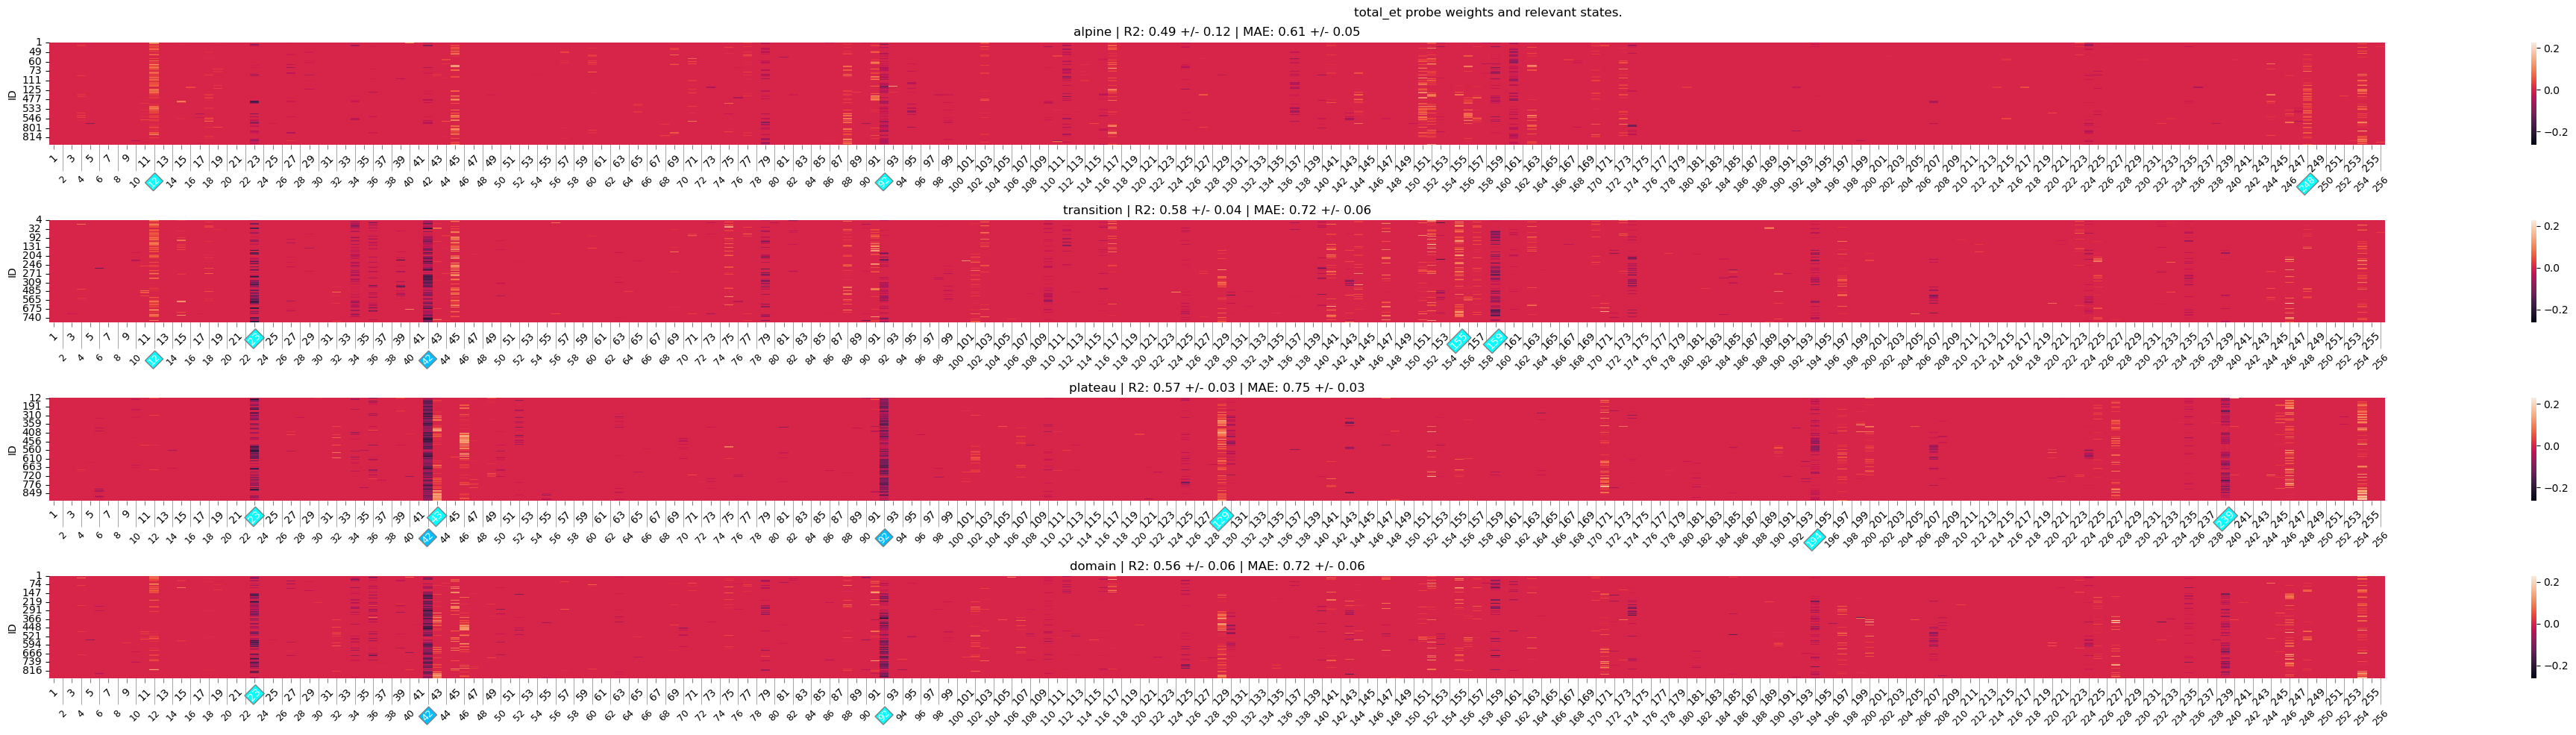

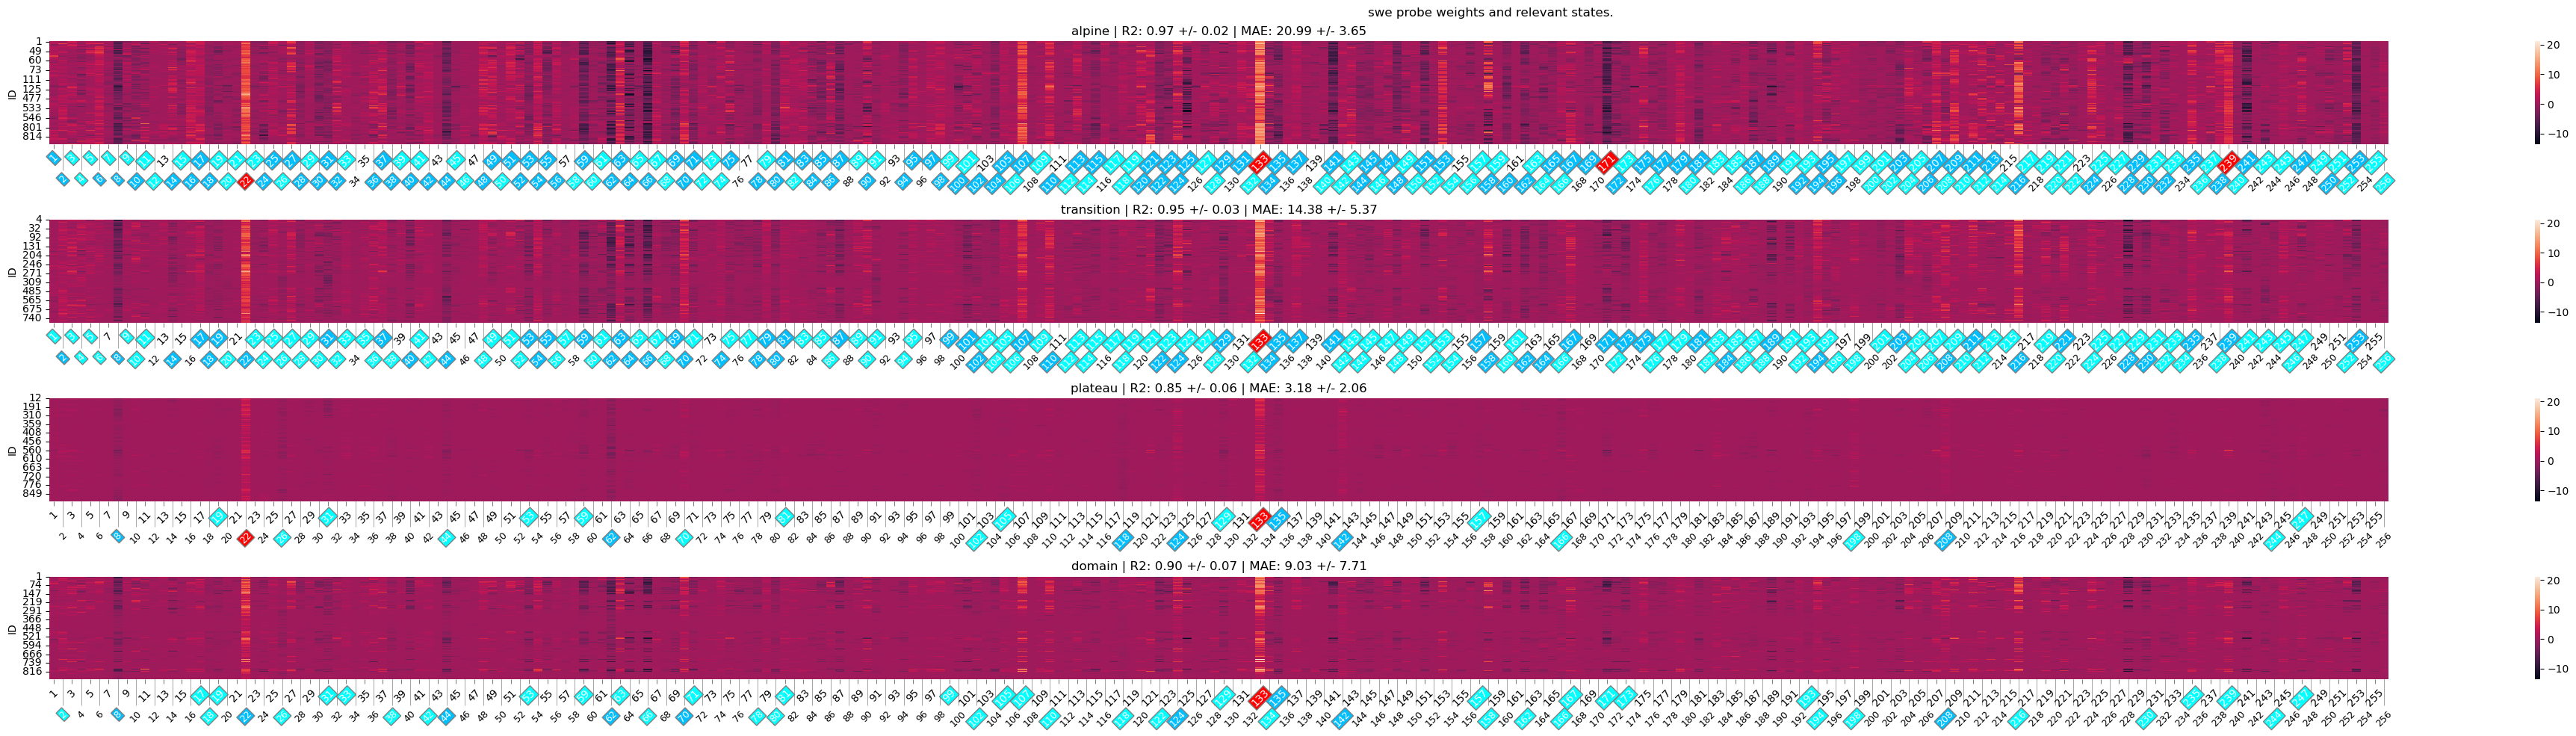

In [8]:
# dict to store state relevances
var_relevant_states = {}
var_name_list = ["temp", "prec", "total_et", "swe"]

for probe, name in zip([temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
                       var_name_list):
	
	#plot temp split between the three strata with the relevant states mark accordingly 
	relevance_level_colors = {
		0.5: "aqua",
		0.75: "deepskyblue",
		1.0 : "red"
	}

	#probe = prec_basin_probe_results

	rtwos_df = pd.DataFrame([probe[b]["R2"] for b in probe.keys()], index=strata_ids.index)
	maes_df = pd.DataFrame([probe[b]["MAE"] for b in probe.keys()], index=strata_ids.index)

	# stack weights and convert to df.
	weights = [probe[b]["coef"] for b in probe.keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack, index=strata_ids.index)

	fig, axs = plt.subplots(4,1, figsize=(40,10))

	strata_relevant_states_df = pd.DataFrame(columns=range(1,257))

	for id, ax in zip([0,2,1,3], axs.ravel()):

		# only filter ids in the stratas.
		selected_basin_ids = strata_ids[strata_ids["0"] == id].index if not id == 3 else strata_ids.index

		# Filter out all basins not in the current strata. 
		selected_basin_weights = weights_df.loc[selected_basin_ids, :]
		state_relevance_list = [0]*256

		selected_basins_mean_r2 = float(rtwos_df.loc[selected_basin_ids,0].mean())
		selected_basins_std_r2 = float(rtwos_df.loc[selected_basin_ids,0].std())
		selected_basins_mean_mae = float(maes_df.loc[selected_basin_ids,0].mean())
		selected_basins_std_mae = float(maes_df.loc[selected_basin_ids,0].std())
		
		for threshold in [0.5, 0.75, 1.0]: 
			
			counter = 0

			# Check for each column (weight) how often it ist larger than 0
			for col in selected_basin_weights.columns: 

				if relevance_check(selected_basin_weights.loc[:,col], threshold):
					state_relevance_list[col]=threshold
					counter += 1

			strata_name = strata_labels[id] if not id == 3 else "domain"

			#print(f"{name} in {strata_name} strata has {counter} cell states with >= {threshold*100}% participation.") 

		# after iteration of all threshold save final state relevances for strata to df
		strata_relevant_states_df.loc[strata_name,:] = np.array(state_relevance_list)

		sns.heatmap(selected_basin_weights, ax=ax, vmax=weights_df.max(axis=None), vmin=weights_df.min(axis=None))
		ax.set_title(f"{strata_name} | R2: {selected_basins_mean_r2:.2f} +/- {selected_basins_std_r2:.2f} | MAE: {selected_basins_mean_mae:.2f} +/- {selected_basins_std_mae:.2f}")
		
		# nest x-axis to allow for all state ids to be displayed without cluttering
		ticks_odd = np.arange(0.5, 256, 2)
		labels_odd = [str(i) for i in range(1, 257, 2)]
		
		ticks_even = np.arange(1.5, 256, 2)
		labels_even = [str(i) for i in range(2, 257, 2)]

		ax.set_xticks(ticks_odd)
		ax.set_xticklabels(labels_odd)
		ax.tick_params(axis='x', length=4, color="gray", labelrotation=45) 

		sec_ax = ax.secondary_xaxis('bottom')
		sec_ax.spines["bottom"].set_position(("outward", 25)) 
		sec_ax.set_xticks(ticks_even)
		sec_ax.set_xticklabels(labels_even, fontsize=9)	
		sec_ax.tick_params(axis='x', direction='in', length=40, width=0.5, color='gray', labelrotation=45) 
		sec_ax.spines["bottom"].set_color("none")

		all_axes = [(ax, ticks_odd, labels_odd), (sec_ax, ticks_even, labels_even)]
		
		for current_ax, ticks, labels in all_axes:
					
			tick_labels = current_ax.get_xticklabels()
			
			for text_obj in tick_labels:
				
					state_num = int(text_obj.get_text())
					
					# shift state_num (which is the state label (1-indexed)) by one to align with 0-indexed list of state_relevance_list
					state_relevance = state_relevance_list[state_num-1]
					
					if state_relevance in relevance_level_colors.keys():
						
						color = relevance_level_colors[state_relevance]

						# Bounding Box setzen
						text_obj.set_bbox(dict(
							facecolor=color, 
							edgecolor='gray', 
							boxstyle='square',
							pad=0.1 
						))
						if not color == "lightblue": 
							text_obj.set_color("white")
	
	var_relevant_states[name] = strata_relevant_states_df

	fig.suptitle(f"{name} probe weights and relevant states.")
	plt.tight_layout()

	if save_figs: 
		fig.savefig(f"/home/wuhlmann/BA/repo/lamah-ce_lstm/results/probing/{name}_probe_weights_and_important_states.png")


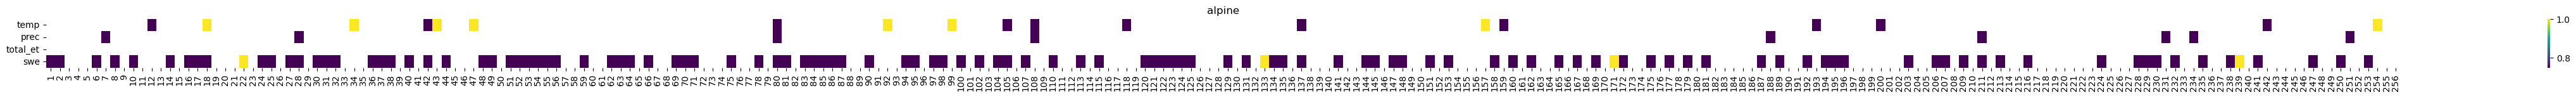

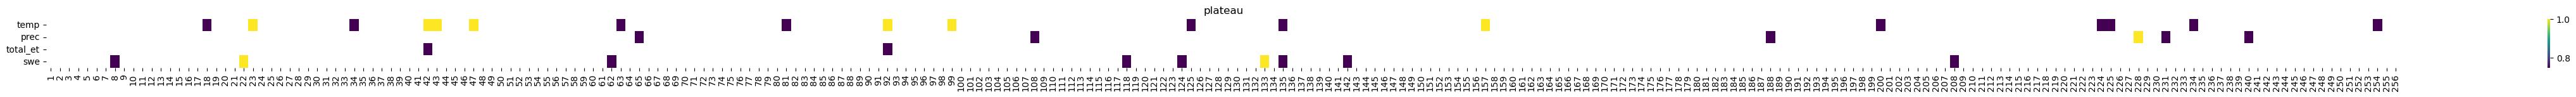

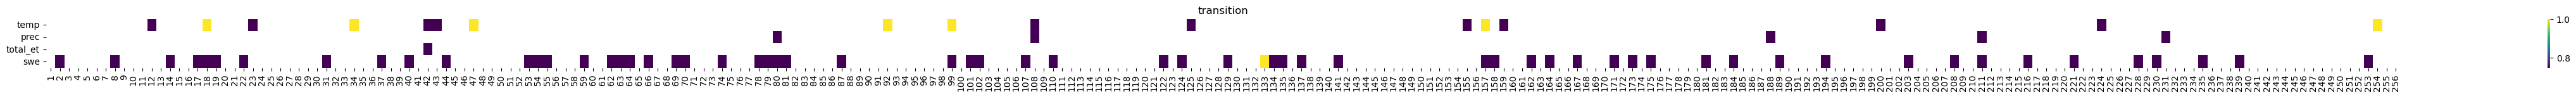

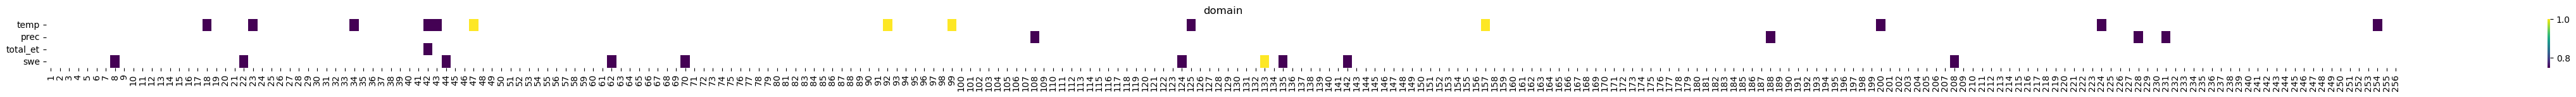

In [9]:
for strata in list(strata_labels.values()) + ["domain"]:
	var_domain_relevance_df = pd.DataFrame(data=[var_relevant_states[var].loc[strata] for var in var_name_list], index=var_name_list)

	fig, ax = plt.subplots(1,1, figsize=(60,1))
	sns.heatmap(var_domain_relevance_df[var_domain_relevance_df > 0.5], cmap="viridis")
	ax.set_title(strata)

In [8]:
weights_df.mean(axis=0).shape

(256,)

In [7]:
# try out std importance score 
for probe_results, name in zip([temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
							   ["temp", "prec", "total_et", "swe"]): 
	
	weights = [probe_results[b]["coef"] for b in probe_results.keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack, index=strata_ids.index)

	# get std of average weight vector
	sd = weights_df.mean(axis=0).std()

	print(f"Relevant cells for representing:{name}")

	for cell_state in weights_df:

		cell_state_col = weights_df.loc[:,cell_state]

		# mean weight over all basins
		mean_cs_value = abs(cell_state_col.mean())

		# determine percentage of basins where the cell is active
		activity = (cell_state_col !=0).sum() / len(cell_state_col) 

		if mean_cs_value // sd >=2:

			# importance score is the floor quotient of mean weight value and std of that cell state vector, multiplied with fraction of times the weight was above zero 
			print(cell_state+1, f"{(mean_cs_value//sd * activity):.2f}")


Relevant cells for representing:temp
18 3.00
23 3.73
34 2.92
42 3.93
43 4.99
47 6.00
92 4.00
99 3.00
125 2.80
157 4.00
200 2.92
224 2.87
254 3.00
Relevant cells for representing:prec
7 2.76
65 1.48
80 1.93
108 6.89
181 0.75
188 5.79
211 2.19
228 4.90
231 3.88
234 0.66
240 1.27
Relevant cells for representing:total_et
23 3.56
42 8.47
92 4.38
129 0.80
239 0.76
246 0.61
254 0.86
Relevant cells for representing:swe
8 1.89
22 5.99
59 1.45
62 2.83
66 1.01
70 1.55
107 1.95
133 8.00
216 1.58


temp Always on: Index([17, 46, 91, 98, 156], dtype='int64') 
Always off: Index([  0,   7,  37,  50,  52,  57,  58,  61,  82,  83,  84,  96, 103, 108,
       118, 119, 132, 133, 135, 141, 144, 147, 148, 164, 182, 185, 201, 205,
       218, 228, 249],
      dtype='int64')

prec Always on: Index([], dtype='int64') 
Always off: Index([  0,   4,   5,   9,  10,  13,  15,  16,  26,  31,
       ...
       216, 220, 221, 222, 237, 238, 244, 248, 249, 251],
      dtype='int64', length=102)

total_et Always on: Index([], dtype='int64') 
Always off: Index([  0,   1,   4,   6,   7,   8,  12,  13,  19,  20,  21,  24,  25,  30,
        32,  37,  40,  47,  50,  52,  54,  57,  58,  61,  63,  71,  73,  77,
        82,  83,  84,  86,  88,  92,  95,  96,  99, 103, 108, 114, 117, 118,
       120, 121, 122, 125, 130, 132, 133, 135, 137, 141, 144, 145, 148, 149,
       153, 159, 164, 165, 167, 168, 174, 175, 178, 182, 185, 186, 187, 194,
       197, 200, 202, 203, 205, 208, 210, 212, 214, 217, 218, 221, 227,

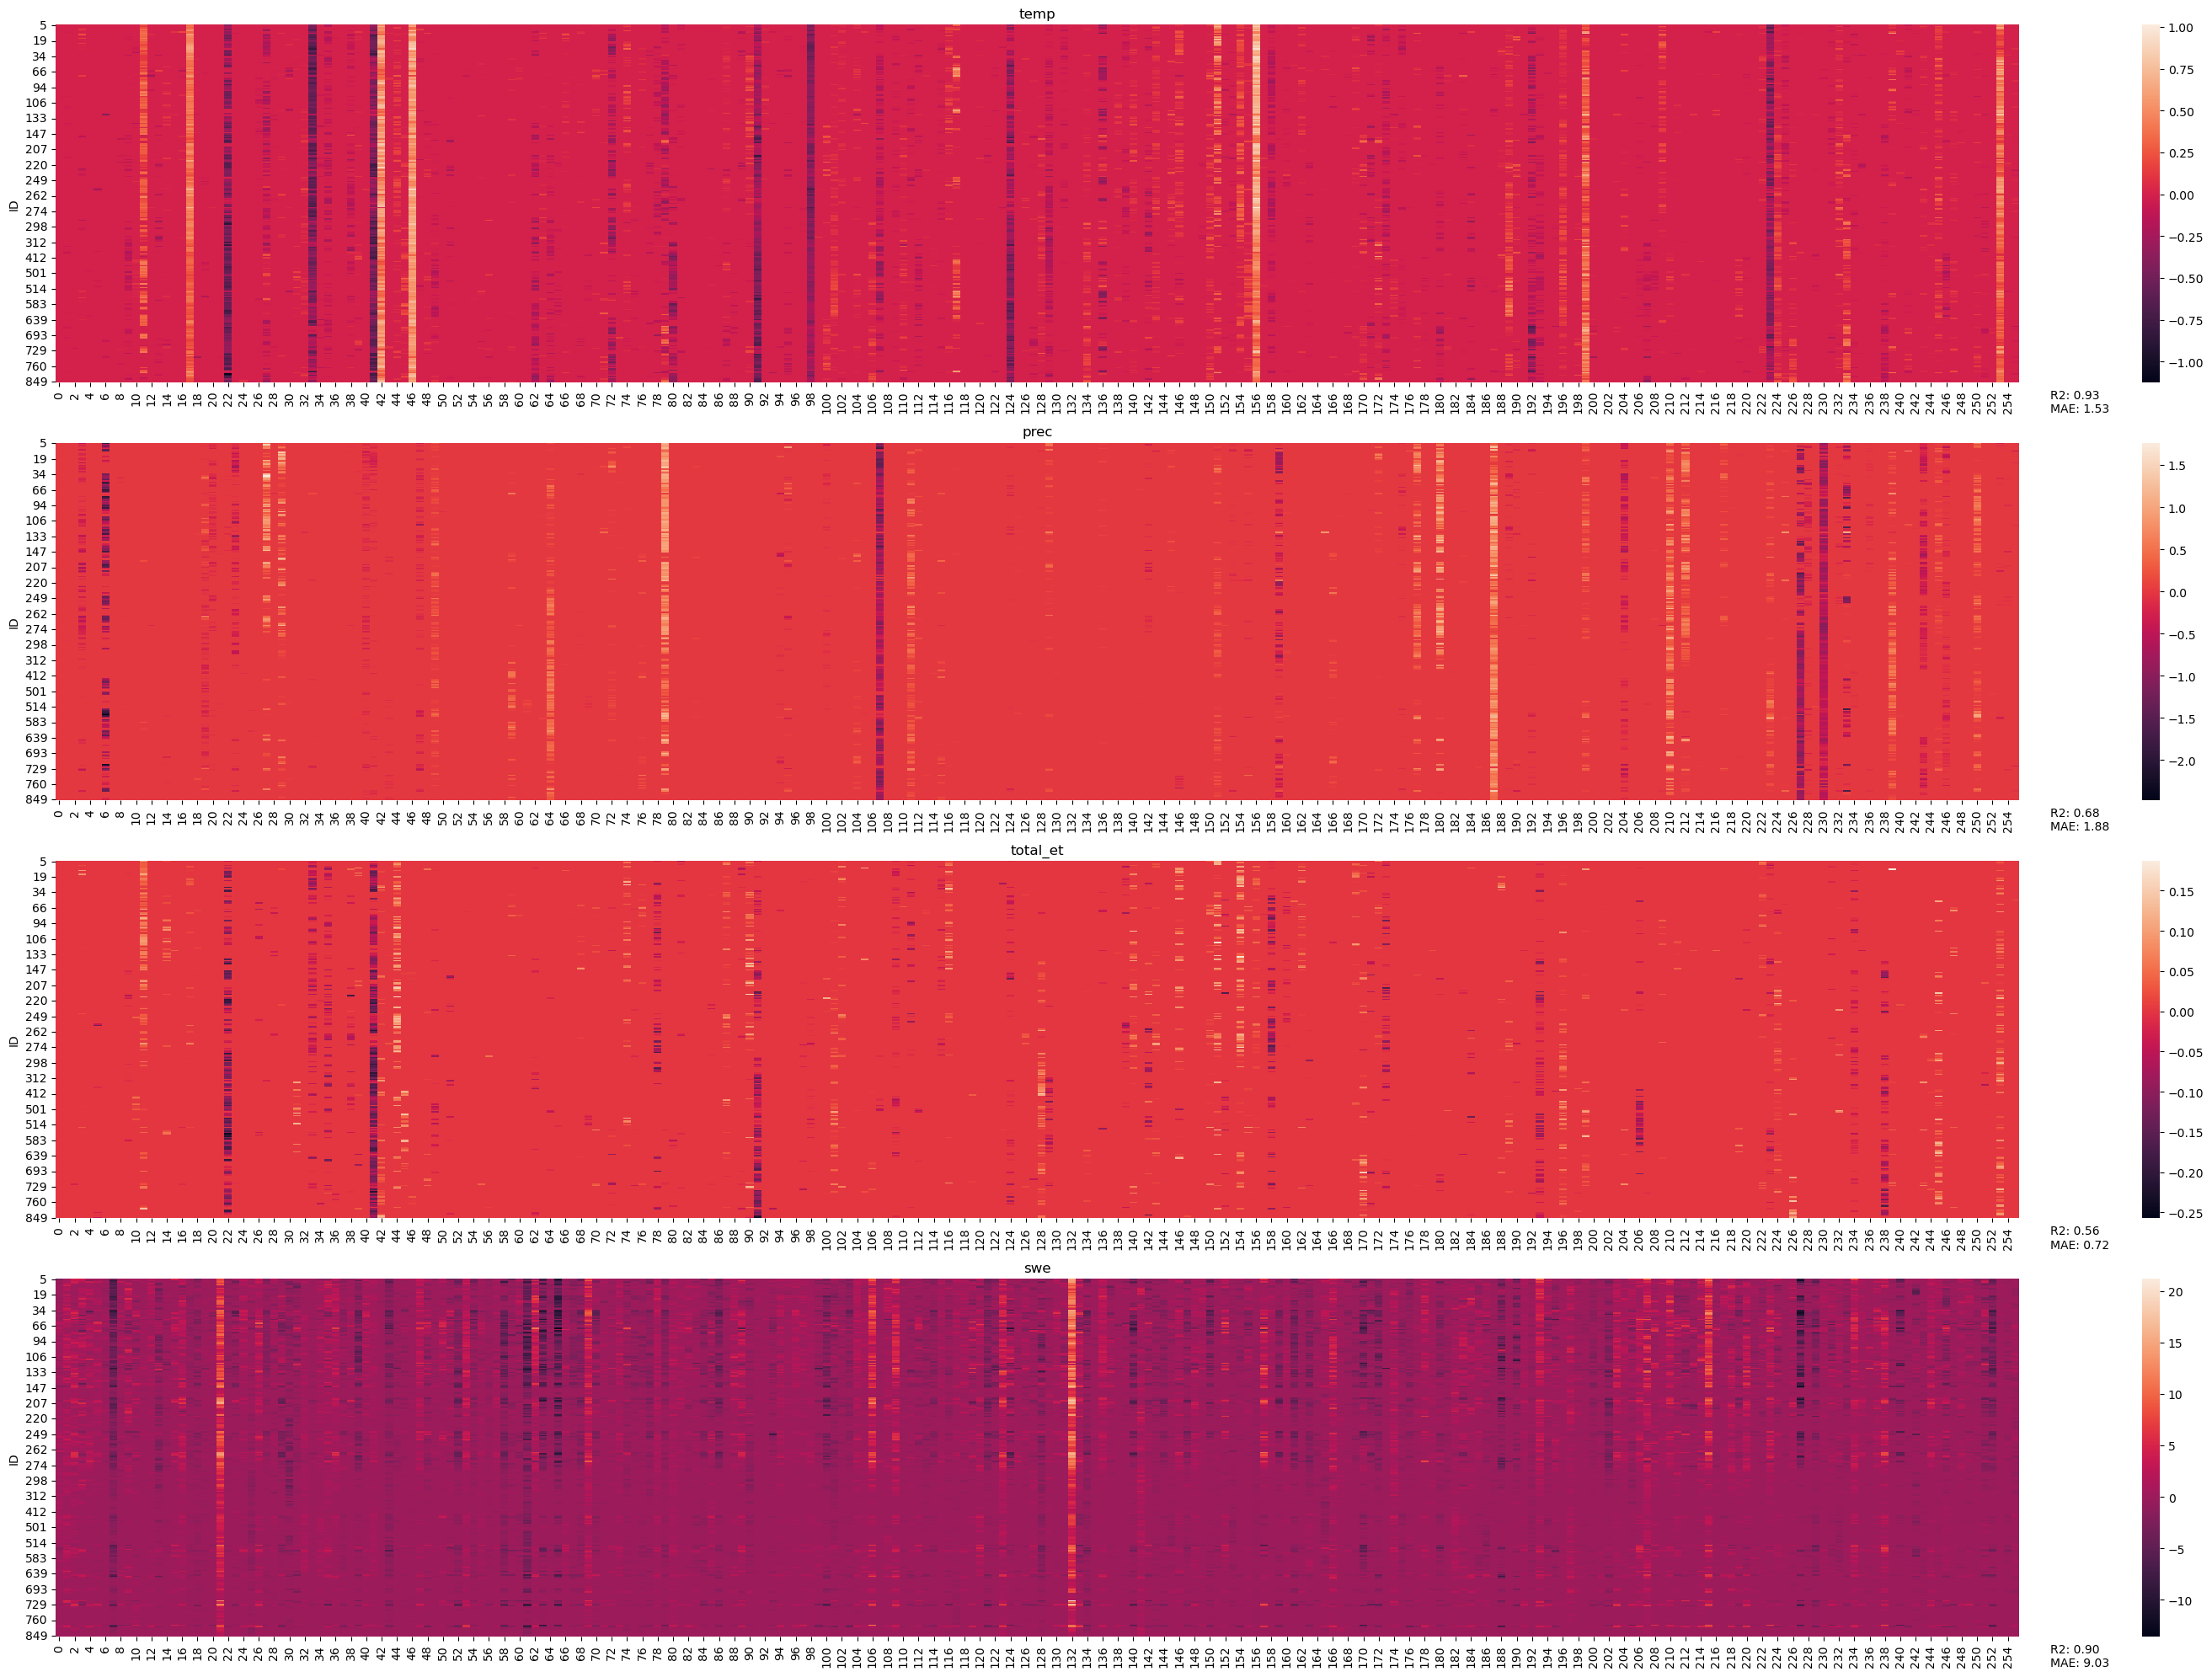

In [11]:
fig, axs = plt.subplots(4,1, figsize=(30,20))


w_l = []

for ax, probe, name in zip(
	axs,[temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
	["temp", "prec", "total_et", "swe"]
):

	rtwos = [probe[b]["R2"] for b in probe.keys()]
	maes = [probe[b]["MAE"] for b in probe.keys()]
	weights = [probe[b]["coef"] for b in probe.keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack, index=strata_ids.index)
	w_l.append(weights_df)

	select_ids = list(strata_ids[strata_ids["0"] == 2].index)
	selected_weights_df = weights_df.iloc[select_ids,:]

	sns.heatmap(selected_weights_df, ax=ax)
	ax.text(x=260, y=300, s=f"R2: {np.mean(rtwos):.2f} \nMAE: {np.mean(maes):.2f}")
	ax.set_title(name)

	always_on= (selected_weights_df != 0).all()
	always_off = (selected_weights_df == 0).all()
	print(f"{name} Always on: {always_on.index[always_on]} \nAlways off: {always_off.index[always_off]}\n")

if save_figs:
	fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/basin_probe_weights.png", dpi=300)

plt.tight_layout()



In [12]:
for id in [0,1,2]: 

	print(strata_labels[id])

	strata_basins = strata_ids[strata_ids["0"] == id].index

	for var_w_df, var in zip(w_l, ["temp", "prec", "total_et", "swe"]):

		var_w_df = var_w_df.set_index(strata_ids.index)

		# Filter out all basins not in the current strata. 
		var_w_df = var_w_df.loc[strata_basins,:]

		counter = 0
		relevant_states = []

		for col in var_w_df.columns: 

			if relevance_check(var_w_df.loc[:,col], 1):
				relevant_states.append(col)
				counter += 1

		print(f"{var} : {counter} cell states relevant : {relevant_states}") 

alpine
temp : 8 cell states relevant : [17, 33, 42, 46, 91, 98, 156, 253]
prec : 0 cell states relevant : []
total_et : 0 cell states relevant : []
swe : 4 cell states relevant : [21, 132, 170, 238]
plateau
temp : 7 cell states relevant : [22, 41, 42, 46, 91, 98, 156]
prec : 1 cell states relevant : [227]
total_et : 0 cell states relevant : []
swe : 2 cell states relevant : [21, 132]
transition
temp : 7 cell states relevant : [17, 33, 46, 91, 98, 156, 253]
prec : 0 cell states relevant : []
total_et : 0 cell states relevant : []
swe : 1 cell states relevant : [132]


In [13]:
strata_relevance_dict = {} 

for id, name in strata_labels.items(): 

	strata_basins = strata_ids[strata_ids["0"] == id].index
	state_relevance_dict = {}

	for var_w_df, var in zip(w_l, ["temp", "prec", "total_et", "swe"]):

		var_w_df = var_w_df.set_index(strata_ids.index)

		var_w_df = var_w_df.loc[strata_basins,:]

		var_relevance_dict = defaultdict(list)

		for col in var_w_df.columns: 

			for relevance_level in [0.75, 1.0]: 

				if relevance_check(var_w_df.loc[:,col], relevance_level): 
					
					var_relevance_dict[relevance_level].append(col)

		state_relevance_dict[var] = var_relevance_dict
	
	strata_relevance_dict[name] = state_relevance_dict

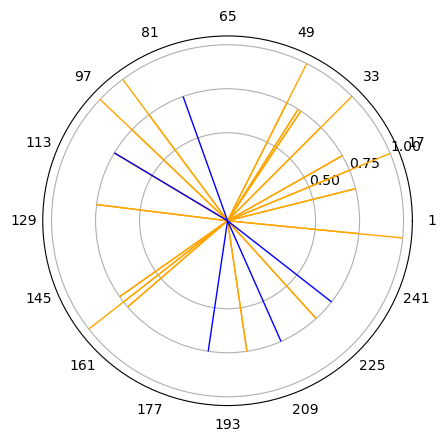

In [14]:
ax = plt.subplot(111, projection="polar")
angles = np.linspace(0,2*np.pi, 256, endpoint=False)

ax.set_xticks(angles[::16])
ax.set_xticklabels(range(1,256, 16), rotation=45)
ax.xaxis.grid(False)
ax.set_yticks([0.5,0.75,1.0])

for var, color in zip(list(state_relevance_dict.keys())[:2], ["orange", "blue", "black", "gray"][:2]):

	state_relevance_lines = [0]*256

	for level, relevant_state_list in state_relevance_dict[var].items(): 

		for cell in relevant_state_list:

			state_relevance_lines[cell-1] = level

		ax.vlines(angles, 0, state_relevance_lines, linewidth=1, colors=color)

In [15]:
plt.rcParams['figure.dpi'] = 100

In [16]:
strata_relevance_dict.keys()

dict_keys(['alpine', 'plateau', 'transition'])

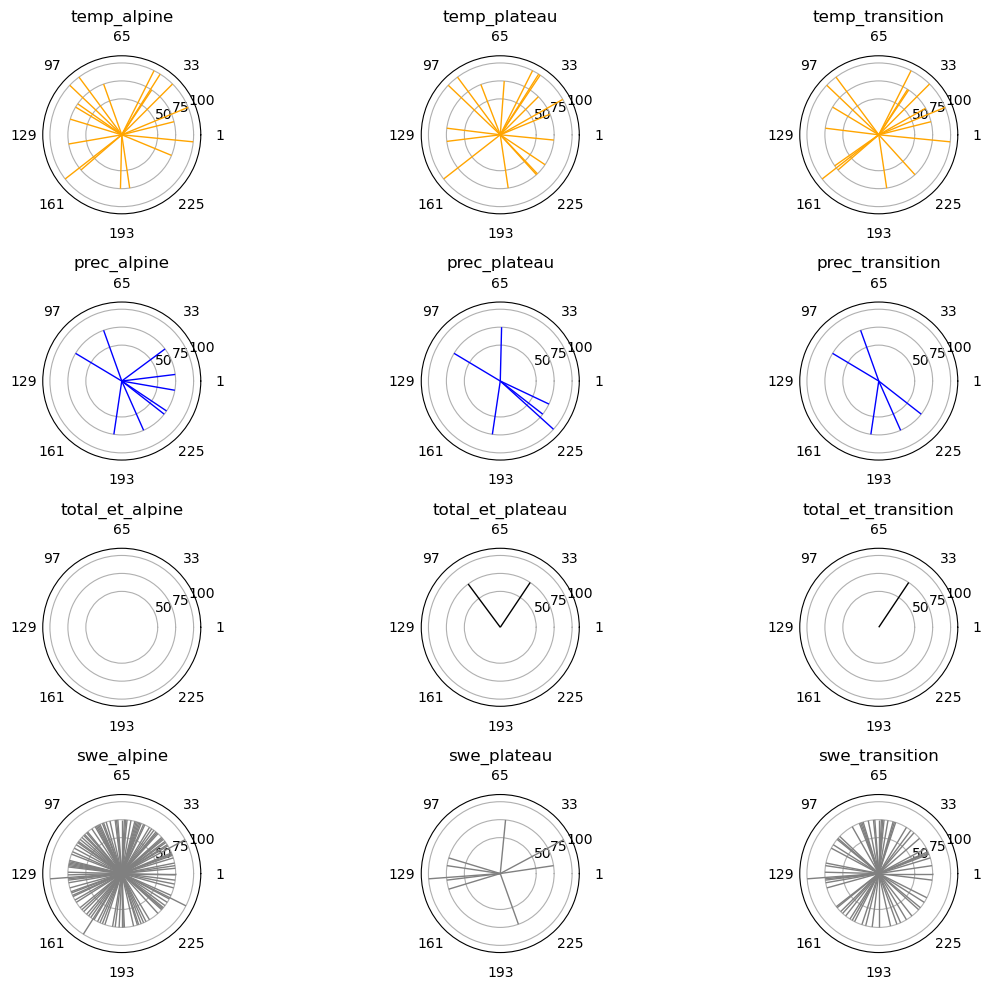

In [17]:
fig, axs = plt.subplots(4,3, subplot_kw=dict(projection="polar"), figsize=(12, 10))

angles = np.linspace(0, 2*np.pi, 256, endpoint=False)
colors = ["orange", "blue", "black", "gray"]
vars = list(strata_relevance_dict["alpine"].keys())

for ax in axs.ravel():

	ax.set_xticks(angles[::32])
	ax.set_xticklabels(range(1, 256, 32), rotation=45)
	ax.set_yticks([0.5, 0.75, 1.0])
	ax.set_yticklabels([50, 75, 100])
	ax.set_ylim(0,1.1)
	ax.xaxis.grid(False)

for col, strata in zip(range(axs.shape[1]), strata_relevance_dict.keys()):
	
	ax_col = axs[:, col]
	
	for i in range(4): 

		var_levels = strata_relevance_dict[strata][vars[i]]

		state_relevance_lines = [0]*256

		for level, cells in var_levels.items():
			
			for cell in cells:
				state_relevance_lines[cell-1] = level
		
		ax_col[i].vlines(angles, 0, state_relevance_lines, linewidth=1, color=colors[i])
		ax_col[i].set_title(f"{vars[i]}_{strata}")
			
plt.tight_layout()

Separate the weights by strata and look for locally important cell states.

In [18]:
#load .shp and sort index 
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf.sort_index(ascending=True, inplace=True)

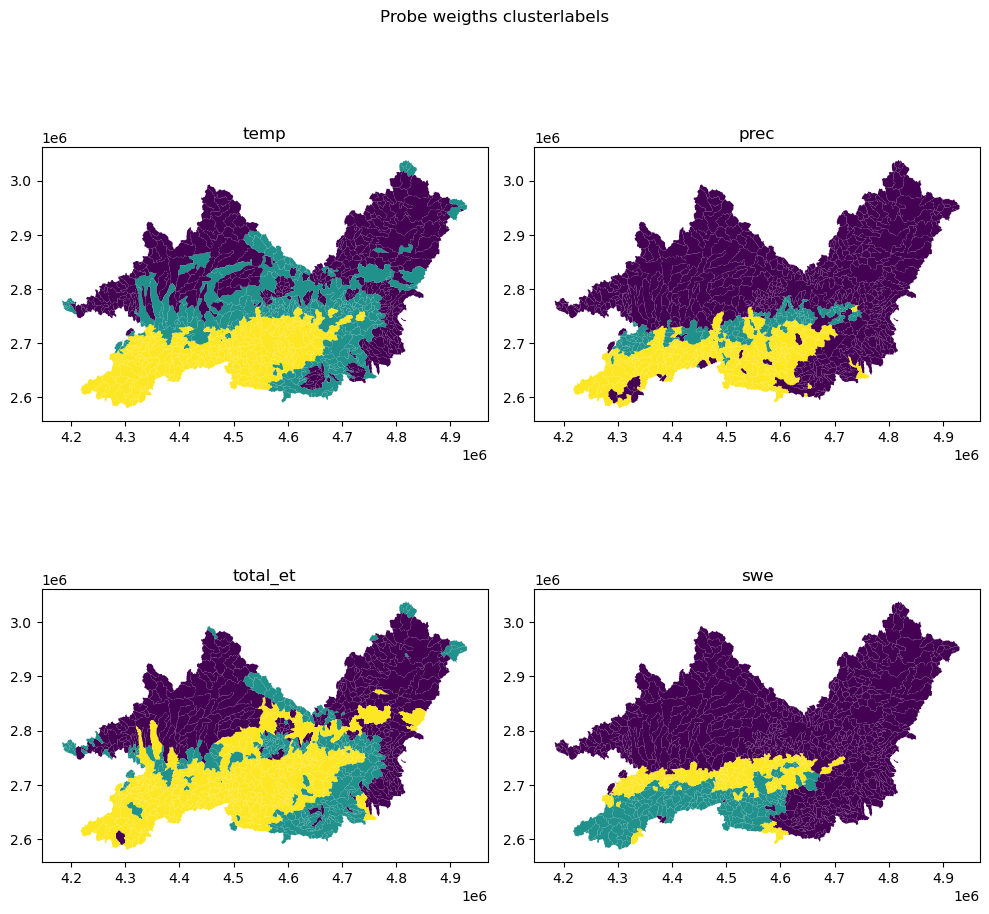

In [19]:
fig, axs = plt.subplots(2,2, figsize=(10,10))
fig.suptitle("Probe weigths clusterlabels")
kmeans = KMeans(3, random_state=134414)

for ax, probe, name in zip(
	axs.ravel(),
	[temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
	["temp", "prec", "total_et", "swe"]
	):

	weights = [probe[b]["coef"] for b in probe.keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack)
	
	probe_weights_labels = kmeans.fit_predict(weights_df)	

	col = f"{name}_labels"
	lamah_gdf[col] = probe_weights_labels
	lamah_gdf.plot(column=col, ax=ax)
	ax.set_title(f"{name}")

if save_figs:
	fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/basin_probe_weigths_cluster.png", dpi=300)

plt.tight_layout()

In [20]:
lamah_gdf.columns

Index(['area_calc', 'elev_mean', 'elev_med', 'elev_std', 'elev_ran',
       'slope_mean', 'mvert_dist', 'mvert_ang', 'elon_ratio', 'strm_dens',
       'p_mean', 'et0_mean', 'eta_mean', 'arid_1', 'arid_2', 'p_season',
       'frac_snow', 'hi_prec_fr', 'hi_prec_du', 'hi_prec_ti', 'lo_prec_fr',
       'lo_prec_du', 'lo_prec_ti', 'lc_dom', 'agr_fra', 'bare_fra',
       'forest_fra', 'glac_fra', 'lake_fra', 'urban_fra', 'lai_max',
       'lai_diff', 'ndvi_max', 'ndvi_min', 'gvf_max', 'gvf_diff', 'bedrk_dep',
       'root_dep', 'soil_poros', 'soil_condu', 'soil_tawc', 'sand_fra',
       'silt_fra', 'clay_fra', 'grav_fra', 'oc_fra', 'gc_dom', 'gc_ig_fra',
       'gc_mt_fra', 'gc_pa_fra', 'gc_pb_fra', 'gc_pi_fra', 'gc_py_fra',
       'gc_sc_fra', 'gc_sm_fra', 'gc_ss_fra', 'gc_su_fra', 'gc_va_fra',
       'gc_vb_fra', 'gc_wb_fra', 'geol_perme', 'geol_poros', 'NEXTDOWNID',
       'geometry', 'temp_labels', 'prec_labels', 'total_et_labels',
       'swe_labels'],
      dtype='object')

<Axes: >

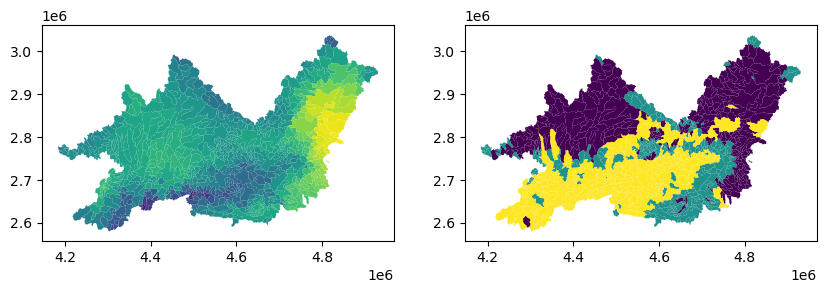

In [21]:
fig, axs = plt.subplots(1,2, figsize=(10,10))



lamah_gdf.plot(column="et0_mean", ax=axs[0])
lamah_gdf.plot(column="total_et_labels", ax=axs[1])



Maybe do MDS on probe weights, to identify possible clusters beyond the 3 stratas.

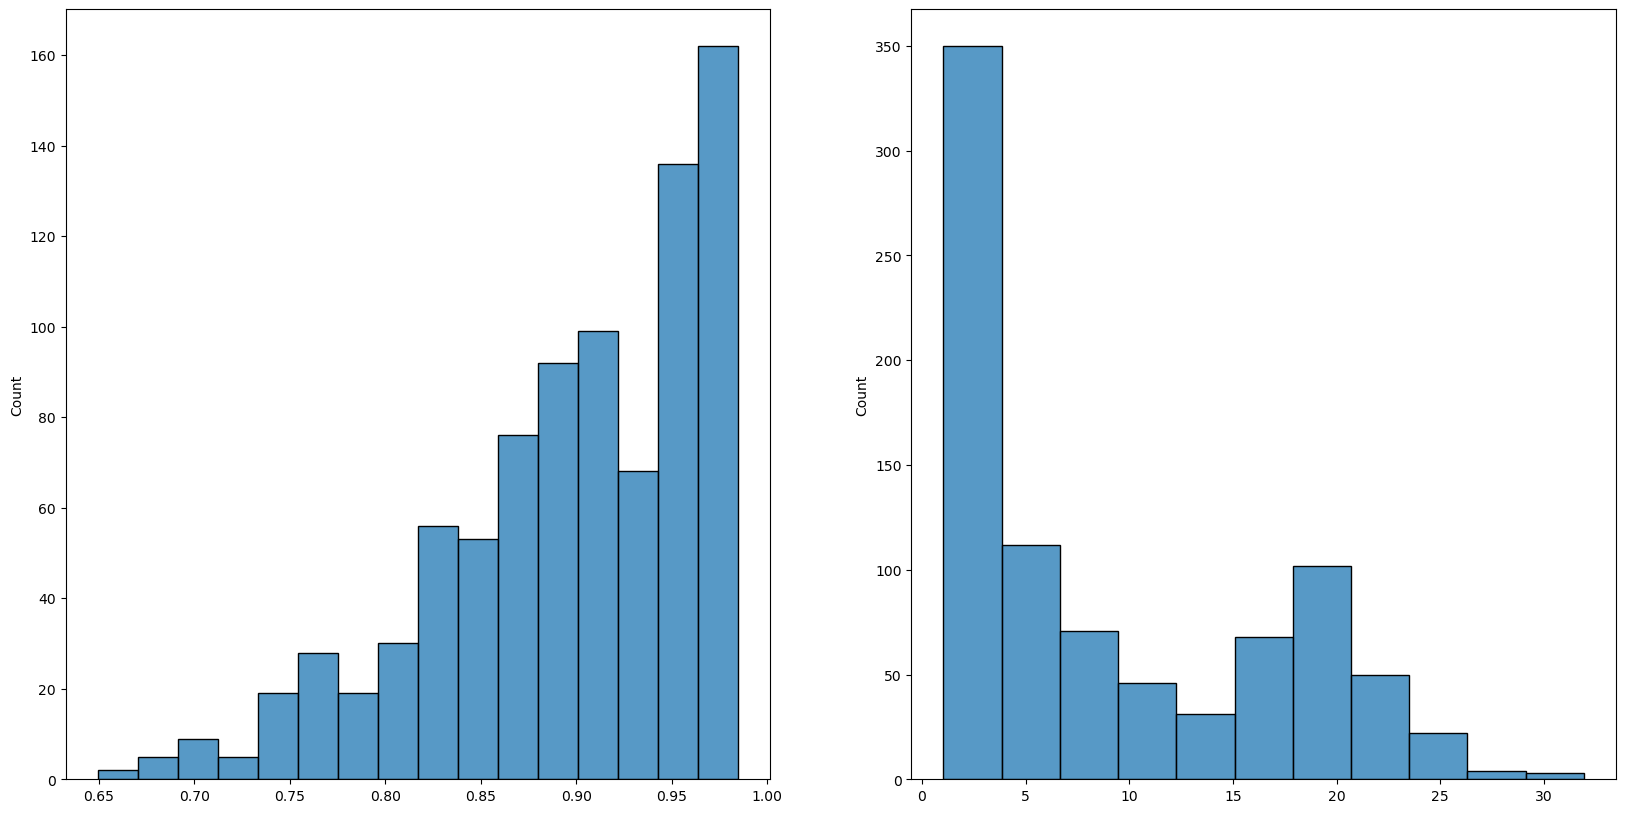

In [22]:
fig, axs = plt.subplots(1,2, figsize=(20,10))

for ax, metric in zip(axs, [rtwos, maes]): 
	
	sns.histplot(metric, ax=ax)

### Domain probes

Note: original study could only train probe for swe, after filtering out non-snow-melt basins.

In [ ]:
with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_2m_temp_mean_domain_probe.p", "rb") as f: 
	temp_domain_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_prec_domain_probe.p", "rb") as f: 
	prec_domain_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_total_et_domain_probe.p", "rb") as f: 
	total_et_domain_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_swe_domain_probe.p", "rb") as f: 
	swe_domain_probe_results = pickle.load(f)

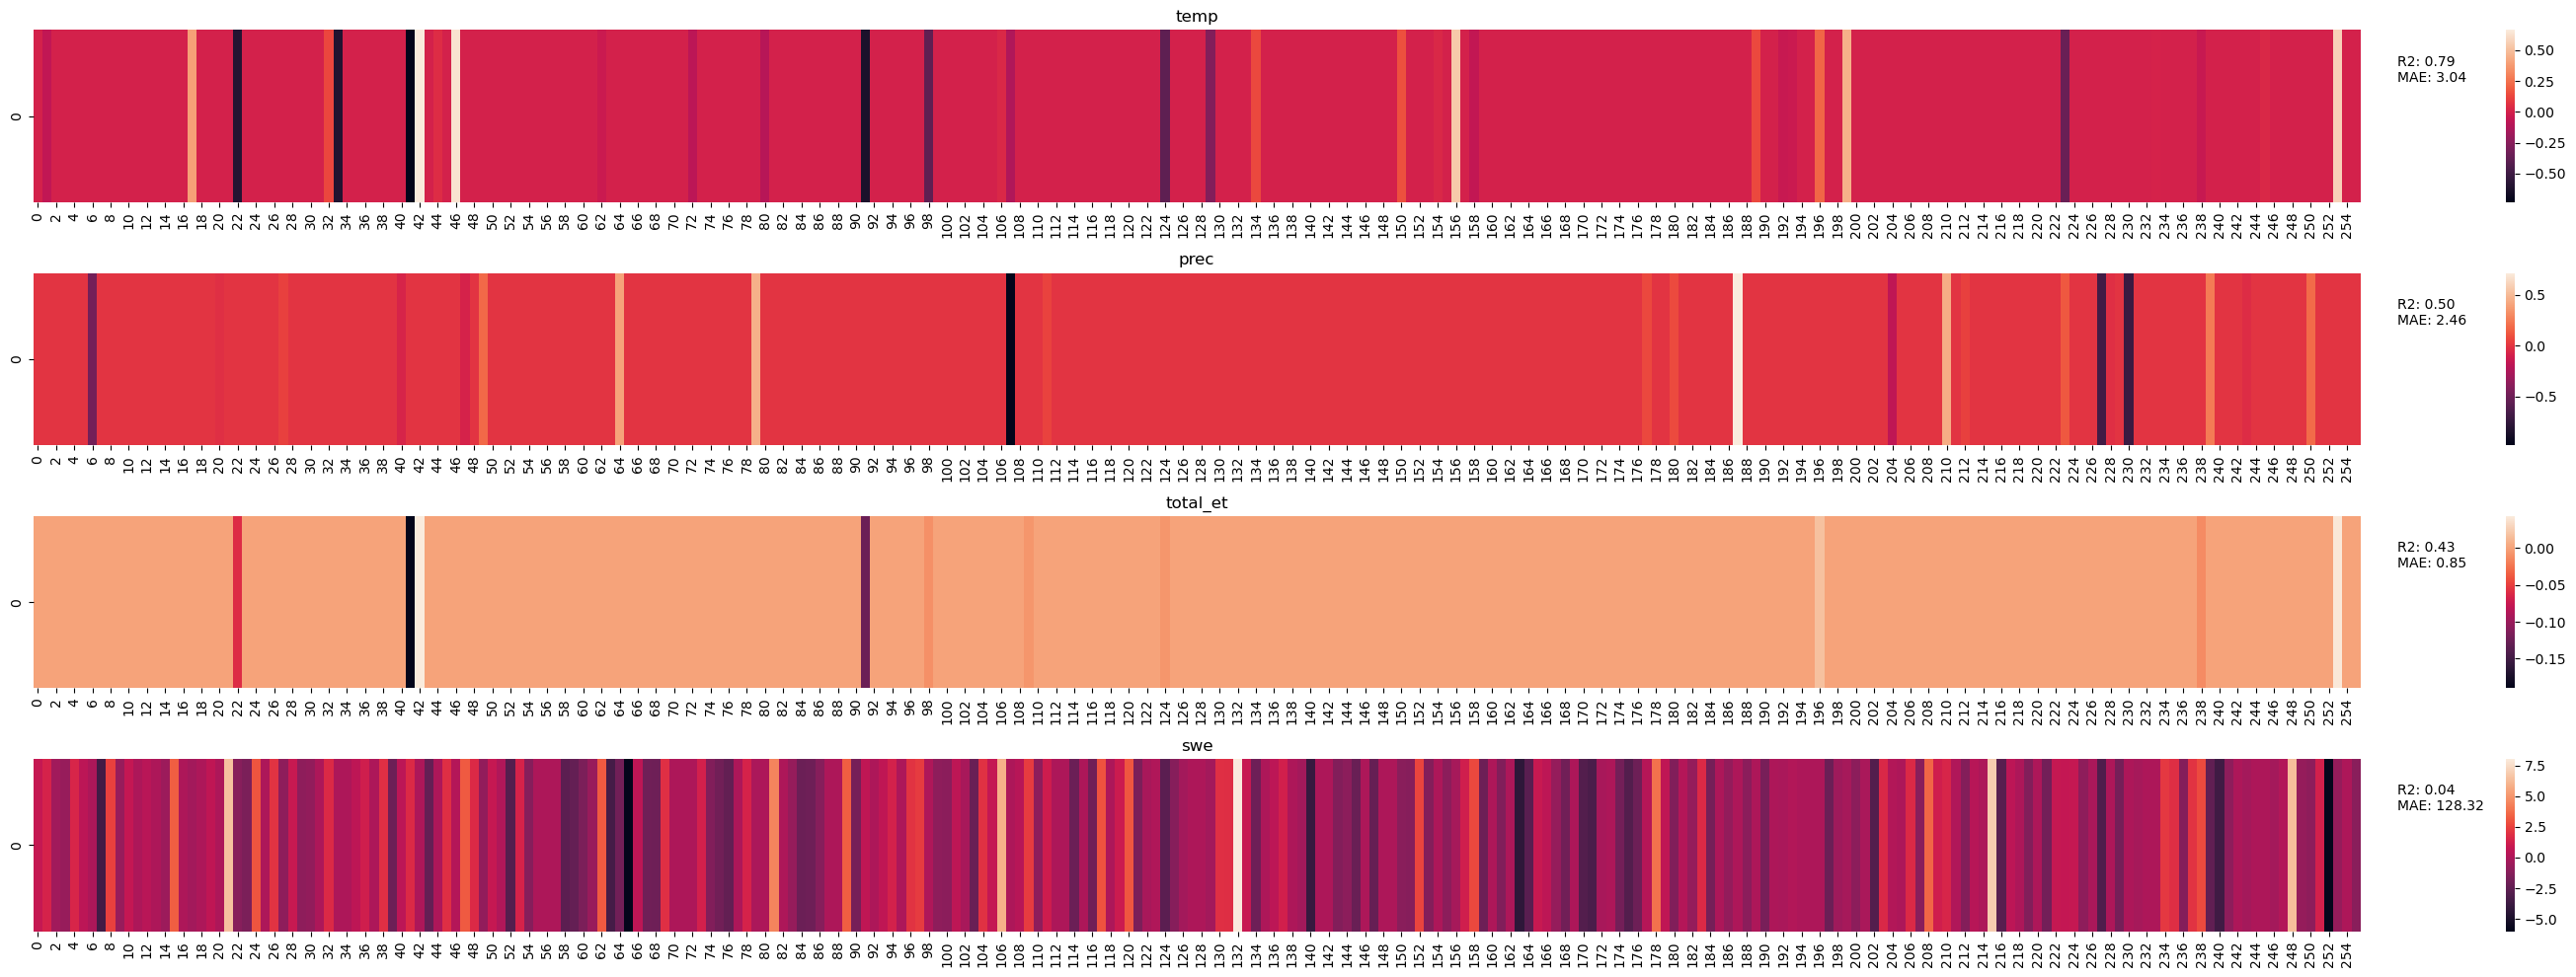

In [ ]:
fig, axs = plt.subplots(4,1, figsize=(30,10))

for ax, probe, name in zip(
	axs.ravel(),
	[temp_domain_probe_results, prec_domain_probe_results, total_et_domain_probe_results, swe_domain_probe_results],
	["temp", "prec", "total_et", "swe"]):

	sns.heatmap(np.reshape(probe["train_results"]["model"].coef_,(1,256)), ax=ax)
	ax.text(x=260, y=0.3, s=f"R2: {probe['train_results']['R2']:.2f} \nMAE: {probe['train_results']['MAE']:.2f}")
	ax.set_title(name)


plt.tight_layout()

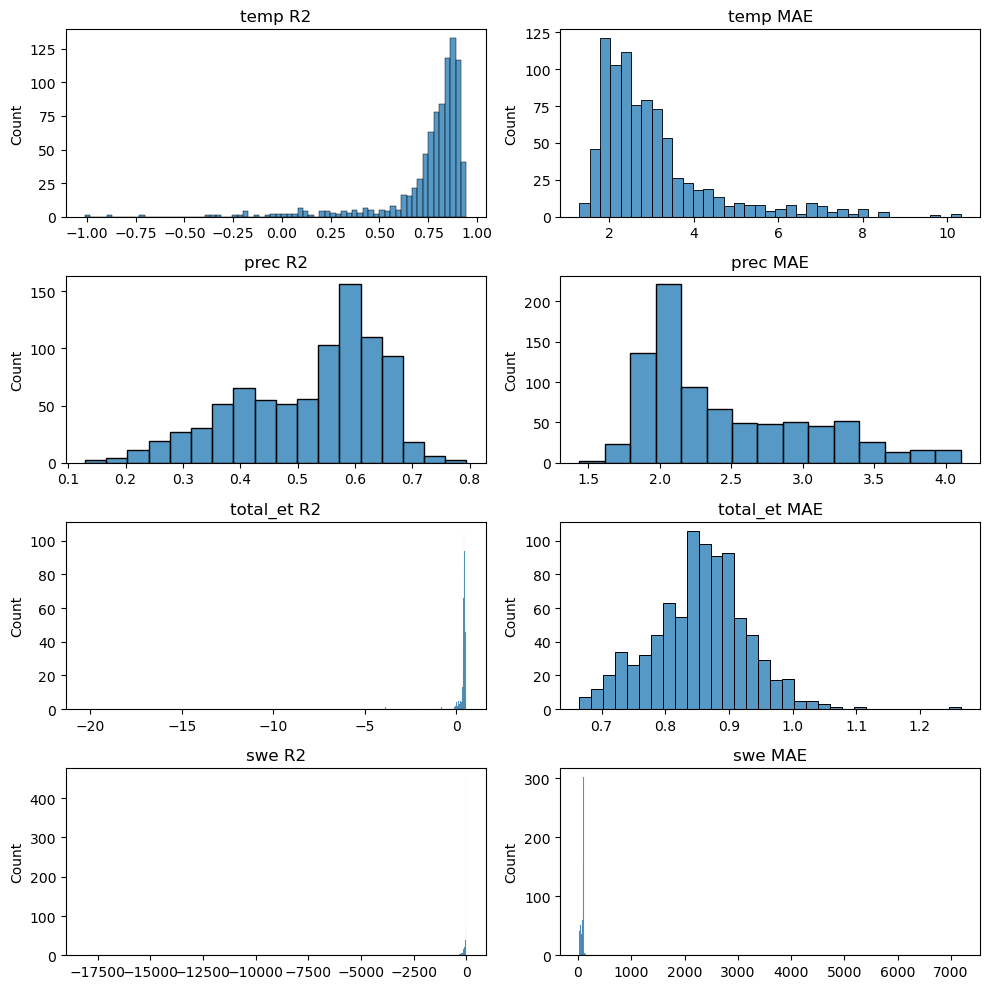

In [ ]:
fig, axs = plt.subplots(4,2, figsize=(10,10))
axs = axs.ravel()

for i, probe, name in zip(
	list(range(0,8,2)),
	[temp_domain_probe_results, prec_domain_probe_results, total_et_domain_probe_results, swe_domain_probe_results],
	["temp", "prec", "total_et", "swe"]
	):
	 
	basin_keys = list(probe.keys())[1:]

	basins_r2 = [probe[b]["R2"] for b in basin_keys]
	basins_mae = [probe[b]["MAE"] for b in basin_keys]

	sns.histplot(basins_r2, ax=axs[i])
	axs[i].set_title(f"{name} R2")
	sns.histplot(basins_mae, ax=axs[i+1])
	axs[i+1].set_title(f"{name} MAE")

plt.tight_layout()